# Example - Permutation Feature Importance

This notebook demonstrates:
1. Training a regression model
2. Computing permutation feature importance

## 1. Imports

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score
from sklearn.inspection import permutation_importance
from sklearn.tree import DecisionTreeRegressor

import matplotlib.pyplot as plt

## 2. Load Dataset

In [2]:
df = pd.read_csv("insurance.csv")

print(df.head())
print(df.info())

   age  gender     bmi  children smoker     region  insurance_cost
0   18    male  33.770         1     no  southeast      1725.55230
1   18    male  34.100         0     no  southeast      1137.01100
2   18  female  26.315         0     no  northeast      2198.18985
3   18  female  38.665         2     no  northeast      3393.35635
4   18  female  35.625         0     no  northeast      2211.13075
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             1338 non-null   int64  
 1   gender          1338 non-null   object 
 2   bmi             1338 non-null   float64
 3   children        1338 non-null   int64  
 4   smoker          1338 non-null   object 
 5   region          1338 non-null   object 
 6   insurance_cost  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None


## 3. Basic Data Preparation Decisions

In [3]:
# Target variable
TARGET = "insurance_cost"

In [4]:
# Binary mapping for gender and smoker
df["gender"] = df["gender"].map({"male": 1, "female": 0})
df["smoker"] = df["smoker"].map({"yes": 1, "no": 0})

In [5]:
# Discretise age into ordinal groups
df["age_group"] = pd.cut(df["age"],
                          bins=[0, 30, 50, 100],
                          labels=[0, 1, 2])

df["age_group"] = df["age_group"].astype(int)

# Drop original age
df = df.drop(columns=["age"])

## 4. Features and Target

In [6]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

In [7]:
# Identify column types
numeric_features = ["bmi", "children", "age_group", "gender", "smoker"]
categorical_features = ["region"]

## 5. Data Preparation Pipeline

In [8]:
# Numeric pipeline
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical pipeline
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine pipelines
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

## 6. Full Training Pipeline

In [9]:
model = DecisionTreeRegressor(max_depth=4, random_state=42)

pipe = Pipeline([
    ("preprocessing", preprocessor),
    ("model", model)
])

## 7. Train/Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 8. Train and Evaluate Model

In [11]:
pipe.fit(X_train, y_train)

# Evaluate
y_pred = pipe.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f"R2: {r2:.2f}")

R2: 0.86


## 9. Permutation Feature Importance

Important: evaluate on test data to measure generalisation performance.

In [12]:
result = permutation_importance(
    pipe,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

## 10. Display Results

In [13]:
feature_names = X_test.columns

importances = pd.Series(result.importances_mean, index=feature_names)
importances = importances.sort_values(ascending=False)

print("\nPermutation Feature Importance:")
print(importances)


Permutation Feature Importance:
smoker       1.512624
bmi          0.283009
age_group    0.164516
children     0.007234
region       0.000979
gender      -0.002142
dtype: float64


## 11. Plot

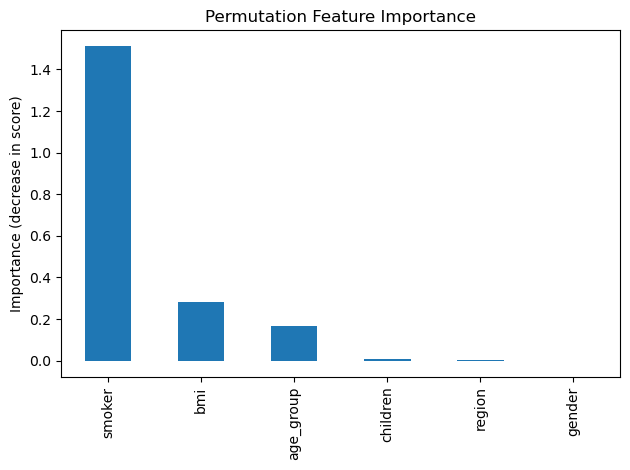

In [14]:
importances.plot(kind="bar")
plt.title("Permutation Feature Importance")
plt.ylabel("Importance (decrease in score)")
plt.tight_layout()
plt.show()

## 12. Interpretation Questions

- Which feature is most important?
- Does this make sense from a domain perspective?
- Are any features surprisingly unimportant?
- What happens if you remove low-importance features?